# 🎯 Classification (التصنيف) Lab
**Day 3 — Core Algorithms**

---

Classification (التصنيف) predicts a **category** (class) rather than a number. Today you'll train three different classifiers and compare them:

1. **Logistic Regression** — the linear Classification (التصنيف) boundary from the animation
2. **Decision Tree** — learns a tree of if-then rules
3. **K-Nearest Neighbors (KNN)** — classifies by looking at nearby examples

Dataset: **Customer Churn** — can we predict which customers will cancel their service?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings; warnings.filterwarnings("ignore")

# Churn dataset (synthetic but realistic)
np.random.seed(42)
n = 600
tenure    = np.random.randint(1, 73, n)  # months as customer
monthly   = np.random.uniform(20, 110, n).round(2)
total     = (tenure * monthly * np.random.uniform(0.9, 1.1, n)).round(2)
support   = np.random.randint(0, 10, n)  # support calls
internet  = np.random.choice(["DSL", "Fiber", "No"], n, p=[0.3, 0.5, 0.2])

# Churn probability: higher for short tenure, high support calls, fiber internet
churn_prob = (
    0.6 - 0.008*tenure + 0.03*support
    + 0.1*(internet == "Fiber") + 0.05*(monthly > 70)
).clip(0.05, 0.95)
churn = (np.random.random(n) < churn_prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly_charges": monthly, "total_charges": total,
    "support_calls": support, "internet_service": internet, "churn": churn
})

print("Dataset shape:", df.shape)
print(f"Churn rate: {df['churn'].mean():.1%}  ({df['churn'].sum()} churned out of {len(df)})")
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (600, 6)
Churn rate: 47.7%  (286 churned out of 600)

First 5 rows:
   tenure  monthly_charges  total_charges  support_calls internet_service  \
0      52           105.03        4998.56              3            Fiber   
1      15            96.47        1548.69              2              DSL   
2      72            42.26        3039.77              6               No   
3      61            60.55        3679.21              5              DSL   
4      21            31.62         676.29              6            Fiber   

   churn  
0      1  
1      0  
2      0  
3      0  
4      0  


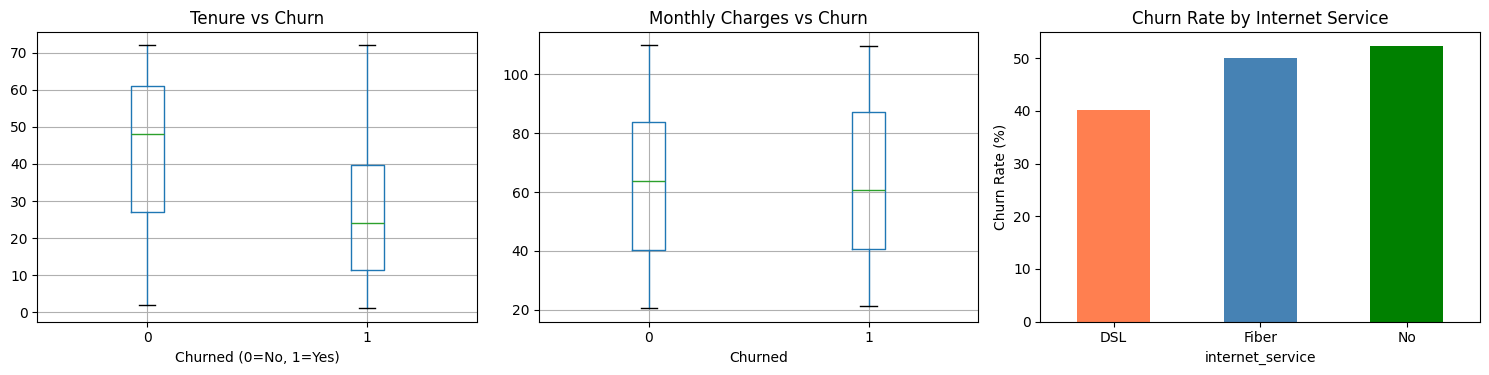

In [2]:
# EDA: what predicts churn?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure by churn
df.boxplot(column="tenure", by="churn", ax=axes[0])
axes[0].set_title("Tenure by Churn"); axes[0].set_xlabel("Churned (0=No, 1=Yes)")
plt.sca(axes[0]); plt.title("Tenure vs Churn")

# Monthly charges by churn
df.boxplot(column="monthly_charges", by="churn", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn"); axes[1].set_xlabel("Churned")
plt.sca(axes[1]); plt.title("Monthly Charges vs Churn")

# Churn rate by internet service
churn_by_internet = df.groupby("internet_service")["churn"].mean() * 100
churn_by_internet.plot(kind="bar", ax=axes[2], color=["coral","steelblue","green"])
axes[2].set_title("Churn Rate by Internet Service")
axes[2].set_ylabel("Churn Rate (%)"); axes[2].tick_params(axis="x", rotation=0)

plt.suptitle(""); plt.tight_layout(); plt.show()

In [3]:
# Prepare data: encode categoricals, split, scale
le = LabelEncoder()
df["internet_encoded"] = le.fit_transform(df["internet_service"])

features = ["tenure", "monthly_charges", "support_calls", "internet_encoded"]
X = df[features].values
y = df["churn"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training: {len(X_train)} samples, Test: {len(X_test)} samples")

Training: 480 samples, Test: 120 samples


## Model 1 — Logistic Regression

Despite the name, Logistic Regression is a *Classification (التصنيف)* algorithm. It learns a linear boundary and uses the sigmoid function to output probabilities between 0 and 1.

In [4]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_s, y_train)

y_pred_lr = log_reg.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {acc_lr:.1%}")
print()
print("Learned coefficients (importance of each feature):")
for name, coef in zip(features, log_reg.coef_[0]):
    direction = "↑ more likely to churn" if coef > 0 else "↓ less likely to churn"
    print(f"  {name:25s}: {coef:+.3f}  {direction}")

Logistic Regression Accuracy: 67.5%

Learned coefficients (importance of each feature):
  tenure                   : -0.890  ↓ less likely to churn
  monthly_charges          : +0.077  ↑ more likely to churn
  support_calls            : +0.394  ↑ more likely to churn
  internet_encoded         : +0.142  ↑ more likely to churn


## Model 2 — Decision Tree

A Decision Tree learns a series of if-then rules. It's highly interpretable — you can literally read the tree and understand every decision.

Decision Tree Accuracy: 70.8%
Tree depth: 4
Number of leaves: 16


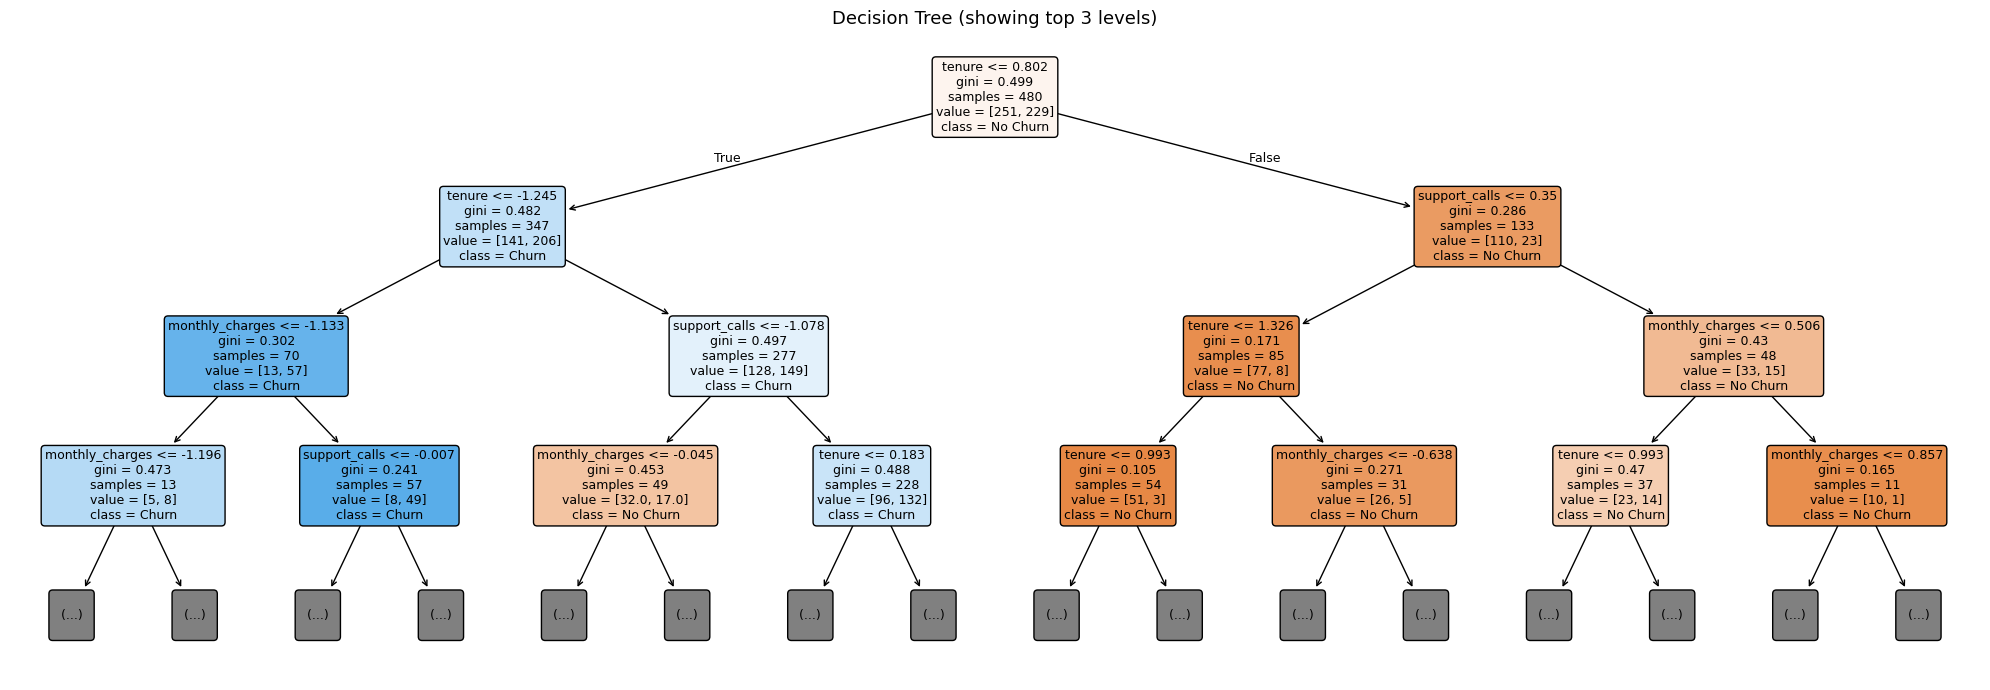


Read the tree from top to bottom:
  Each node shows: the decision rule, gini impurity, sample count, and predicted class


In [5]:
# Train Decision Tree
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train_s, y_train)   # Note: trees don't actually need scaling, but we use it for consistency

y_pred_dt = dtree.predict(X_test_s)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {acc_dt:.1%}")
print(f"Tree depth: {dtree.get_depth()}")
print(f"Number of leaves: {dtree.get_n_leaves()}")

# Visualize the tree (first 3 levels)
plt.figure(figsize=(20, 7))
plot_tree(dtree, feature_names=features, class_names=["No Churn", "Churn"],
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title("Decision Tree (showing top 3 levels)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nRead the tree from top to bottom:")
print("  Each node shows: the decision rule, gini impurity, sample count, and predicted class")

## Model 3 — K-Nearest Neighbors (KNN)

KNN classifies a new point by looking at the K closest examples in the training set and taking a majority vote. It requires no training phase — all the "learning" happens at prediction time.

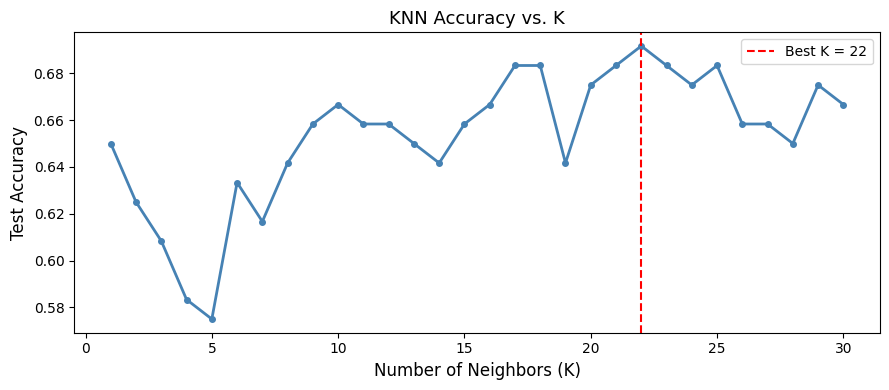

Best K: 22 neighbors → Accuracy: 69.2%


In [6]:
# Try different values of K and find the best
k_values = range(1, 31)
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_s)))

best_k = k_values[np.argmax(test_accuracies)]
best_acc = max(test_accuracies)

plt.figure(figsize=(9, 4))
plt.plot(k_values, test_accuracies, marker="o", markersize=4, color="steelblue", linewidth=2)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("Number of Neighbors (K)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("KNN Accuracy vs. K", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K: {best_k} neighbors → Accuracy: {best_acc:.1%}")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_s, y_train)
y_pred_knn = knn_best.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)

## Model Comparison + Confusion Matrix

Model                       Accuracy
---------------------------------------------
Logistic Regression          67.5%  ████████████████████
Decision Tree (d=4)          70.8%  █████████████████████
KNN (K=22)                   69.2%  ████████████████████


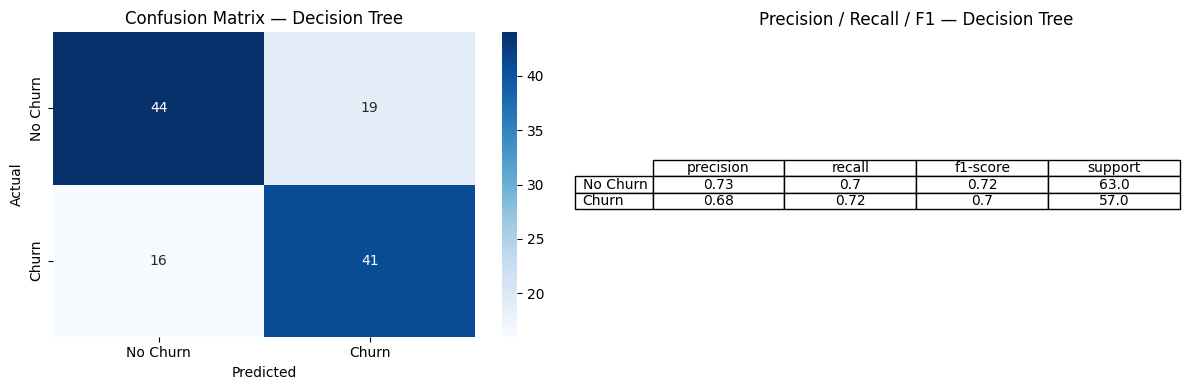


Reading the confusion matrix:
  True Negatives  (correctly predicted No Churn): 44
  False Positives (predicted Churn, actually No):  19
  False Negatives (predicted No Churn, actually): 16
  True Positives  (correctly predicted Churn):    41


In [7]:
# Compare all three models
print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 45)
for name, acc in [("Logistic Regression", acc_lr),
                   ("Decision Tree (d=4)", acc_dt),
                   (f"KNN (K={best_k})", acc_knn)]:
    bar = "█" * int(acc * 30)
    print(f"{name:<25} {acc:>8.1%}  {bar}")
print("=" * 45)

# Confusion matrix for the best model
best_pred = sorted([(acc_lr, y_pred_lr, "Logistic Regression"),
                     (acc_dt, y_pred_dt, "Decision Tree"),
                     (acc_knn, y_pred_knn, f"KNN (K={best_k})")], reverse=True)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, best_pred[1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
axes[0].set_title(f"Confusion Matrix — {best_pred[2]}", fontsize=12)
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

# Classification report as a table
cr = classification_report(y_test, best_pred[1],
     target_names=["No Churn", "Churn"], output_dict=True)
cr_df = pd.DataFrame(cr).T.round(2).iloc[:2]
axes[1].table(cellText=cr_df.values, rowLabels=cr_df.index, colLabels=cr_df.columns,
              loc="center", cellLoc="center")
axes[1].axis("off")
axes[1].set_title(f"Precision / Recall / F1 — {best_pred[2]}", fontsize=12)

plt.tight_layout(); plt.show()

print()
print("Reading the confusion matrix:")
print(f"  True Negatives  (correctly predicted No Churn): {cm[0,0]}")
print(f"  False Positives (predicted Churn, actually No):  {cm[0,1]}")
print(f"  False Negatives (predicted No Churn, actually): {cm[1,0]}")
print(f"  True Positives  (correctly predicted Churn):    {cm[1,1]}")

---
## ✋ Exercise

In [8]:
# Can you improve accuracy by trying a deeper decision tree?
# TASK 1: Train a DecisionTreeClassifier with max_depth=8 and compare to depth=4
# YOUR CODE HERE:

# TASK 2: What is the trade-off of making the tree deeper?
# (Hint: check training accuracy vs test accuracy)
# YOUR CODE HERE:

print("Deeper tree = more complex model = risk of overfitting!")

Deeper tree = more complex model = risk of overfitting!
